# Environmental Science Lab
## Training exercise - fitting a model on a data set

** Student given and family name: ** 

** Date: dd.mm.yyyy ** 

---
## 1) Objective
...

## 2) Experimental Setup
...

## 3) Procedure
...

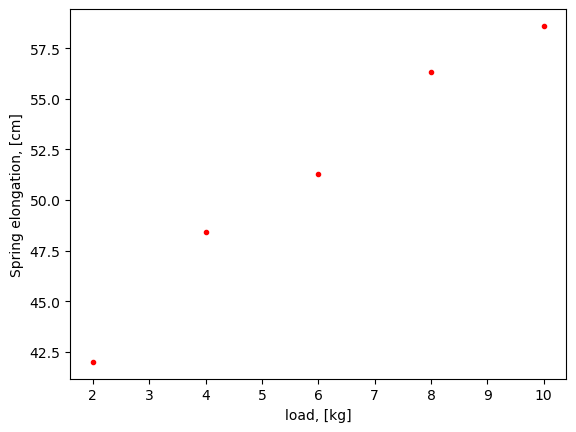

,Mass (kg),elongation (cm)
0,2.0,42.0
1,4.0,48.4
2,6.0,51.3
3,8.0,56.3
4,10.0,58.6


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# enter load value
x = [2,4,6,8,10]
x = np.array(x, dtype=float)

# enter spring elongation value
l = [42.0,48.4,51.3,56.3,58.6]
l = np.array(l, dtype=float)

plt.figure(1)
plt.plot(x,l,'r.')
plt.xlabel("load, [kg]")
plt.ylabel("Spring elongation, [cm]")
plt.show()

# create dataframe
df = pd.DataFrame({
    "Mass (kg)": x,
    "elongation (cm)": l
})

# optional: round values for nicer display
df = df.round({
    "Mass (kg)": 2,
    "elongation (cm)": 2
})
df

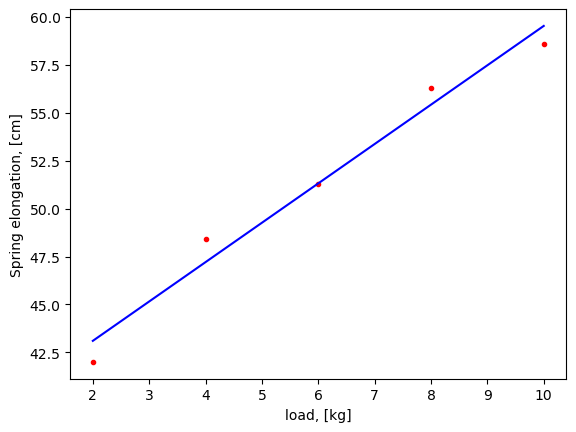

A = 38.99 cm +- 0.97 cm
B = 2.05 cm/kg + - 0.15 cm/kg


,Mass (kg),elongation (cm),Mass squared (kg2),Mass by elongation (kg x cm)
0,2.0,42.0,4.0,84.0
1,4.0,48.4,16.0,193.6
2,6.0,51.3,36.0,307.8
3,8.0,56.3,64.0,450.4
4,10.0,58.6,100.0,586.0


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# sample size
N = len(x)

# compute the parameters A and B of y = A + Bx
x2 = x**2
xl = x*l

A = (np.sum(x2) * np.sum(l) - np.sum(x) * np.sum(xl)) / (N * np.sum(x2) - (np.sum(x)**2))
B = (N * np.sum(xl) - np.sum(x) * np.sum(l)) / (N * np.sum(x2) - (np.sum(x))**2)

sigY = np.sqrt(1/N * np.sum((l - A - B*x)**2))
dA = sigY * np.sqrt((np.sum(x2)) / (N * np.sum(x2) - (np.sum(x)**2)))
dB = sigY * np.sqrt(N / (N * np.sum(x2) - (np.sum(x)**2)))

Y = A + B*x

plt.figure(1)
plt.plot(x,l,'r.')
plt.plot(x,Y,'b')
plt.xlabel("load, [kg]")
plt.ylabel("Spring elongation, [cm]")
plt.show()

print(f"A = {A:.2f} cm +- {dA:.2f} cm")
print(f"B = {B:.2f} cm/kg + - {dB:.2f} cm/kg")

# create dataframe
df = pd.DataFrame({
    "Mass (kg)": x,
    "elongation (cm)": l,
    "Mass squared (kg2)": x2,
    "Mass by elongation (kg x cm)": xl
})

# optional: round values for nicer display
df = df.round({
    "Mass (kg)": 2,
    "elongation (cm)": 2,
    "Mass squared (kg2)": 2,
    "Mass by elongation (kg x cm)": 2
})
df

parameter A = 38.99 [cm]
parameter B = 2.06 [cm/kg]
RMSE = 0.92
Experimental uncertainty sigmaY = 0.92


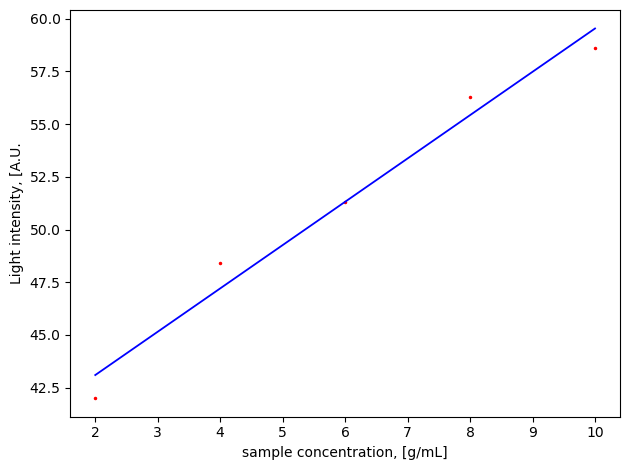

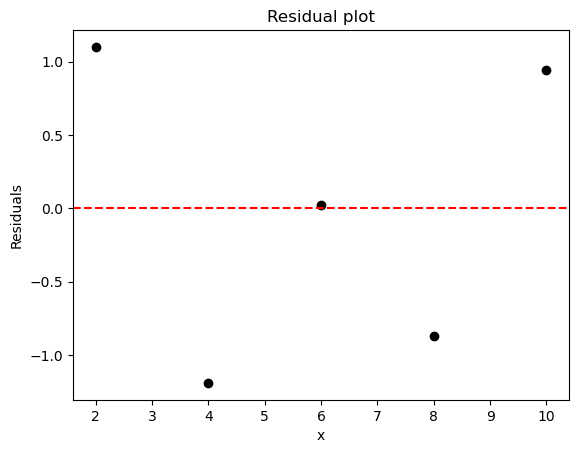

In [25]:
# fit data with Diffusion equation solution
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
import math

# numerical fit
lw = 1.3
ms = 3;

xdata = x
ydata = l
A0 = 1
B0 = 1

# Model function (MUST take x first, then parameters)
def model(x,params):
    A,B = params
    return A + B*x
def residuals(params, x, ydata):
    return model(x, params) - ydata
# Initial guess for parameters
p0 = [A0,B0]

# Perform fit
#popt, pcov = curve_fit(model, xdata, ydata, p0=p0,maxfev=100000)
result = least_squares(residuals, p0, args=(xdata, ydata))
A,B = result.x
res = residuals(result.x, xdata, ydata)

print(f"parameter A = {A:.2f} [cm]")
print(f"parameter B = {B:.2f} [cm/kg]")
RMSE = np.sqrt(np.mean(res**2))
print(f"RMSE = {RMSE:.2f}")
print(f"Experimental uncertainty sigmaY = {sigY:.2f}")

xx = np.linspace(np.min(x),np.max(x),30)
Y = A + B*xx

# Plot
plt.figure(1)
plt.plot(x,l,'r.',linewidth=lw,markersize=ms)
plt.plot(xx,Y,'b-',linewidth=lw,markersize=ms)
plt.xlabel(r"sample concentration, [g/mL]")
plt.ylabel(r"Light intensity, [A.U.")
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(2)
plt.plot(xdata, res, 'ko')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("x")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

parameter A = 2.30
parameter B = 53.21
RMSE = 3.41


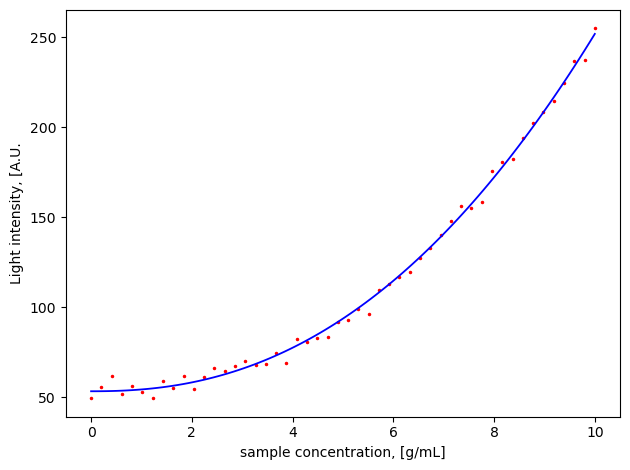

In [39]:
# fit data with Diffusion equation solution
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
import math
rng = np.random.default_rng()

# numerical fit
lw = 1.3
ms = 3;

# sample size
N = 50
# artificial noise definition
mu = 0
s = 3.2
ynoise = rng.normal(mu, s, N)

xdata = np.linspace(0,10,N)
ydata = xdata**2.3 + 53 + ynoise
A0 = 1
B0 = 1

# Model function (MUST take x first, then parameters)
def model(x,params):
    A,B = params
    return xdata**A + B
def residuals(params, xdata, ydata):
    return model(xdata, params) - ydata
# Initial guess for parameters
p0 = [A0,B0]

# Perform fit
#popt, pcov = curve_fit(model, xdata, ydata, p0=p0,maxfev=100000)
result = least_squares(residuals, p0, args=(xdata, ydata))
A,B = result.x
res = residuals(result.x, xdata, ydata)

print(f"parameter A = {A:.2f}")
print(f"parameter B = {B:.2f}")
RMSE = np.sqrt(np.mean(res**2))
print(f"RMSE = {RMSE:.2f}")

xx = np.linspace(np.min(xdata),np.max(xdata),100)
Y = xx**A + B

# Plot
plt.figure(1)
plt.plot(xdata,ydata,'r.',linewidth=lw,markersize=ms)
plt.plot(xx,Y,'b-',linewidth=lw,markersize=ms)
plt.xlabel(r"sample concentration, [g/mL]")
plt.ylabel(r"Light intensity, [A.U.")
plt.grid(False)
plt.tight_layout()
plt.show()

---
### IMPORTANT: Before closing the browser
Go to **File → Download → Notebook (.ipynb)** to save your work.
